In [1]:
# | default_exp dmd_scaling_dataset

# Scaling the MLP

> We try to scale a neural network.

#### Imports and Setup

In [2]:
import os
from ast import literal_eval
from copy import deepcopy

import graphviz
import matrepr
import torch
import torchinfo
from safetensors.torch import load_model, save_model
from torch import nn
from torch.nn import CrossEntropyLoss, L1Loss, MSELoss
from torch.optim import SGD, Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchviz import make_dot

from learningdynamics.datasets import YinYangDataset
from learningdynamics.models import MLP, init_weights
from learningdynamics.utils import (
    compute_model_accuracy,
    getActivation,
    safetensors_metadata_parser,
)
from learningdynamics.visualization import plot_decision_boundary_movie

In [3]:
# | hide
matrepr.params.title = True
matrepr.params.indices = False
matrepr.params.precision = 4
matrepr.cell_align = "left"
graphviz.set_jupyter_format("png")

%matplotlib inline

In [4]:
PRINT_FREQ = 100
device = "cuda:0"

#### Load model trained on binary classification.

In [5]:
file_path = "../saved_weights/model.safetensors"

# Parse metadata
metadata = safetensors_metadata_parser(file_path=file_path)
PROBLEM = metadata["dataset"]

# Load model
model = MLP(
    config=literal_eval(metadata["config"]), nonlinearity=metadata["nonlinearity"]
)
_ = load_model(model, file_path, device="cuda:0")

#### Setup the dataset

In [6]:
NUM_SAMPLES = 2_000

We are using the yinyang dataset


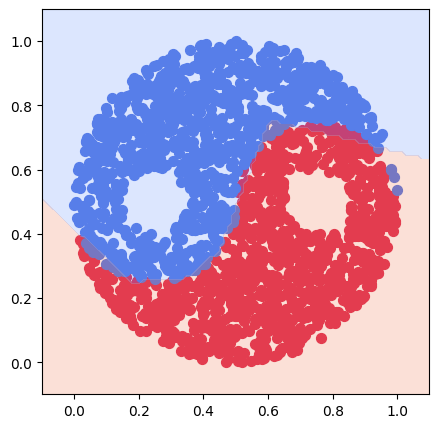

In [7]:
# Build dataset
if PROBLEM == "yinyang":
    dataset = YinYangDataset(num_samples=NUM_SAMPLES, negative_label=False, seed=200)
else:
    raise NotImplementedError("Unsupported dataset.")
print(f"We are using the {PROBLEM} dataset")

# Plot data
plot_decision_boundary_movie(
    model,
    [model.state_dict()],
    dataset.features,
    dataset.labels.squeeze(),
    figsize=(5, 5),
    labels=[0, 1],
)

In [8]:
print(f"Testing Accuracy: {compute_model_accuracy(model, dataset)}")

Testing Accuracy: 0.9739999771118164


In [9]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
MLP                                      --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       18
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       42
│    └─ReLU: 2-4                         --
│    └─Linear: 2-5                       21
│    └─ReLU: 2-6                         --
│    └─Linear: 2-7                       12
│    └─ReLU: 2-8                         --
│    └─Linear: 2-9                       8
Total params: 101
Trainable params: 101
Non-trainable params: 0

#### Scale Model

In [10]:
def freeze_and_scale_model(
    model,
    start,
    layers_to_add=1,
    device="cuda:0",
):
    # Set up scaled model
    model.to(device)
    scaled_model = deepcopy(model)

    # Build new layers
    scaled_container = torch.nn.Sequential()
    for idx, module in enumerate(scaled_model.features):
        if hasattr(module, "weight"):
            module.weight.requires_grad_(False)
        if hasattr(module, "bias"):
            module.bias.requires_grad_(False)
        scaled_container.append(module)
        if idx == start:
            prev_out = model.features[idx - 1].out_features
            for _ in range(layers_to_add):
                linear_layer = nn.Linear(prev_out, prev_out)
                linear_layer.apply(init_weights)
                scaled_container.append(linear_layer)
                scaled_container.append(nn.ReLU())
    scaled_model.features = scaled_container
    scaled_model.to(device=device)

    scaled_model.to(device="cpu")
    return scaled_model

In [11]:
NUM_LAYERS_ADDED = 12
LAYER_START = 1
LAYER_END = 3
BATCH_SIZE = NUM_SAMPLES
NUM_EPOCHS = 5_000
LEARNING_RATE = 5e-3

dataloader = DataLoader(dataset=dataset, shuffle=True, batch_size=BATCH_SIZE)

In [12]:
scaled_model = freeze_and_scale_model(
    model,
    start=LAYER_START,
    layers_to_add=NUM_LAYERS_ADDED,
)

In [13]:
print(f"Testing Accuracy: {compute_model_accuracy(scaled_model.to('cpu'), dataset)}")

Testing Accuracy: 0.4945000112056732


In [14]:
activation_dict = {}
hooks = []

In [15]:
# Setup training
reconstruct_criterion = L1Loss(reduction="sum")
classification_criterion = CrossEntropyLoss()
# optimizer = SGD(scaled_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
optimizer = Adam(scaled_model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=300, threshold=0.0001, verbose=True
)

In [16]:
scaled_model.to(device)
scaled_model.train()

# Attach hook to original
hooks.append(
    model.features[LAYER_END].register_forward_hook(
        getActivation(f"layer_{LAYER_END}", activation_dict)
    )
)

# Attach hook to scaled
new_end = LAYER_END + NUM_LAYERS_ADDED * 2
hooks.append(
    scaled_model.features[new_end].register_forward_hook(
        getActivation(f"scaled_layer_{new_end}", activation_dict, detach=False)
    )
)

# Run training
loss_vector = []
for epoch in range(NUM_EPOCHS):
    running_loss = 0.0  # Track loss within the epoch

    # Iterate through dataloader
    for input, label in dataloader:
        # Feed input in to get activations
        input, label = input.to(device), torch.flatten(label.to(device))
        output = scaled_model(input)

        with torch.no_grad():
            _ = model(input)

        # Zero out optimizer
        optimizer.zero_grad()

        # Grab activations
        output_activation = activation_dict[f"scaled_layer_{new_end}"].to(device)
        target_activation = activation_dict[f"layer_{LAYER_END}"].to(device)

        reconstruction_loss = reconstruct_criterion(
            output_activation, target_activation
        )
        classification_loss = classification_criterion(output, label.long())

        loss = reconstruction_loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item()  # Accumulate loss

    epoch_loss = running_loss / len(dataloader)  # Average loss over all batches
    loss_vector.append(epoch_loss)  # Store loss for later analysis

    # Step the scheduler
    scheduler.step(epoch_loss)

    epoch_loss = running_loss / len(dataloader)  # Average loss over all batches
    loss_vector.append(epoch_loss)  # Store loss for later analysis

    if (epoch + 1) % PRINT_FREQ == 0:
        print(f"Epoch {epoch + 1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}")

# Remove hook
for hook in hooks:
    hook.remove()

Epoch 100/5000, Loss: 1290.2651
Epoch 200/5000, Loss: 1038.1816
Epoch 300/5000, Loss: 1000.0422
Epoch 400/5000, Loss: 954.8895
Epoch 500/5000, Loss: 966.5994
Epoch 600/5000, Loss: 924.2618
Epoch 700/5000, Loss: 865.4290
Epoch 800/5000, Loss: 860.2023
Epoch 900/5000, Loss: 823.2494
Epoch 1000/5000, Loss: 800.1972
Epoch 1100/5000, Loss: 809.6832
Epoch 1200/5000, Loss: 796.8543
Epoch 1300/5000, Loss: 743.7626
Epoch 1400/5000, Loss: 681.5764
Epoch 1500/5000, Loss: 298.1154
Epoch 1600/5000, Loss: 239.2417
Epoch 1700/5000, Loss: 197.7273
Epoch 1800/5000, Loss: 278.5338
Epoch 1900/5000, Loss: 155.5005
Epoch 2000/5000, Loss: 284.7684
Epoch 2100/5000, Loss: 207.2578
Epoch 2200/5000, Loss: 138.0925
Epoch 2300/5000, Loss: 142.1841
Epoch 2400/5000, Loss: 147.8514
Epoch 2500/5000, Loss: 264.3203
Epoch 2600/5000, Loss: 327.1286
Epoch 2700/5000, Loss: 196.3744
Epoch 2800/5000, Loss: 88.7712
Epoch 2900/5000, Loss: 146.4759
Epoch 3000/5000, Loss: 205.6687
Epoch 3100/5000, Loss: 150.1029
Epoch 3200/5000

In [25]:
scaled_model

MLP(
  (features): Sequential(
    (0): Linear(in_features=2, out_features=6, bias=True)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=6, bias=True)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=6, bias=True)
    (5): ReLU()
    (6): Linear(in_features=6, out_features=6, bias=True)
    (7): ReLU()
    (8): Linear(in_features=6, out_features=6, bias=True)
    (9): ReLU()
    (10): Linear(in_features=6, out_features=6, bias=True)
    (11): ReLU()
    (12): Linear(in_features=6, out_features=6, bias=True)
    (13): ReLU()
    (14): Linear(in_features=6, out_features=6, bias=True)
    (15): ReLU()
    (16): Linear(in_features=6, out_features=6, bias=True)
    (17): ReLU()
    (18): Linear(in_features=6, out_features=6, bias=True)
    (19): ReLU()
    (20): Linear(in_features=6, out_features=6, bias=True)
    (21): ReLU()
    (22): Linear(in_features=6, out_features=6, bias=True)
    (23): ReLU()
    (24): Linear(in_features=6, out_features=6, bias=True)
    (25)

In [17]:
scaled_model.eval()
activation_dict

{'scaled_layer_27': tensor([[0.9585, 1.9232, 0.0000, 0.0000, 0.0000, 0.1995],
         [0.5347, 0.9648, 0.4487, 0.0000, 0.0000, 0.8513],
         [0.5056, 1.3426, 0.0000, 0.0000, 0.0000, 1.1978],
         ...,
         [1.4666, 2.5502, 0.1788, 0.0000, 0.1500, 0.0000],
         [0.8832, 1.7826, 0.0000, 0.0000, 0.0000, 0.3233],
         [0.5213, 1.3885, 0.0000, 0.0000, 0.0000, 0.9691]], device='cuda:0',
        grad_fn=<ReluBackward0>),
 'layer_3': tensor([[0.9422, 1.9011, 0.0000, 0.0000, 0.0000, 0.2192],
         [0.5235, 0.9502, 0.4389, 0.0000, 0.0000, 0.8657],
         [0.5022, 1.3302, 0.0000, 0.0000, 0.0000, 1.2138],
         ...,
         [1.4427, 2.5206, 0.1577, 0.0000, 0.1318, 0.0000],
         [0.8677, 1.7614, 0.0000, 0.0000, 0.0000, 0.3431],
         [0.5056, 1.3714, 0.0000, 0.0000, 0.0000, 0.9861]], device='cuda:0')}

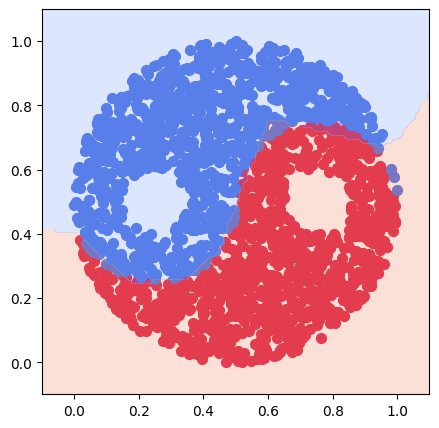

In [18]:
# Plot data
plot_decision_boundary_movie(
    scaled_model,
    [scaled_model.state_dict()],
    dataset.features,
    dataset.labels.squeeze(),
    figsize=(5, 5),
    labels=[0, 1],
)

In [19]:
print(f"Testing Accuracy: {compute_model_accuracy(scaled_model.to('cpu'), dataset)}")

Testing Accuracy: 0.9739999771118164


Update config

In [20]:
config = literal_eval(metadata["config"])
insert = [model.features[LAYER_START - 1].out_features] * NUM_LAYERS_ADDED
config[LAYER_START:LAYER_START] = insert

In [21]:
metadata_dict = {
    "config": str(config),
    "dataset": str(dataset),
    "nonlinearity": metadata["nonlinearity"],
    "added_layers": str(NUM_LAYERS_ADDED),
}
save_model(
    scaled_model, "../saved_weights/scaled_model.safetensors", metadata=metadata_dict
)

In [22]:
metadata_dict

{'config': '[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 3, 3]',
 'dataset': 'yinyang',
 'nonlinearity': 'relu',
 'added_layers': '12'}